# Mamba vs SimpleStories Transformer — Comparative Evaluation

This notebook loads:
* A trained Mamba SSM checkpoint (from `tpu_train.py`)
* The matched SimpleStories pretrained transformer (e.g. `SimpleStories/SimpleStories-5M`)

…and runs six experiments to compare them on the SimpleStories test split:

| # | Experiment | What it measures |
|---|---|---|
| 1 | Test BPB / perplexity / top-k accuracy | Held-out language-model quality |
| 2 | Inference benchmark | Decode tok/s, prefill tok/s, state memory |
| 3 | Loss vs sequence length | Long-context extrapolation (Mamba's design pitch) |
| 4 | Per-position loss | Does the model use its context? |
| 5 | Selective copying / induction | In-context retrieval (Mamba's selectivity claim) |
| 6 | Diversity (self-BLEU / distinct-n / repetition) | Mode collapse / sample variety |

Designed to run on Google Colab (T4 / A100 GPU or CPU). All models load in fp32 by default for fair comparison.


## 1. Setup


In [1]:
# Install dependencies. Skip if already on the host.
%pip install -q torch transformers datasets einops tqdm matplotlib pandas nltk wandb
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)


True

### Get the project source

The notebook needs `mamba/mamba_llm_tpu.py` and `mamba/xla_fused_scan.py` from the
project repo to reconstruct the Mamba model. Adjust `REPO_URL` to your fork.

If you've already uploaded the project files to Colab (or are running locally), set
`REPO_DIR` to the existing path and skip the clone.


In [2]:
import os, sys

REPO_URL = "https://github.com/JackMclaughlin424/csci739-project-mamba.git"
REPO_DIR = "csci739-project-mamba"

if not os.path.isdir(REPO_DIR):
    !git clone {REPO_URL}

if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

# If running locally from the project root, the repo is just the cwd:
if not os.path.exists(os.path.join(REPO_DIR, "mamba")):
    if os.path.exists("mamba"):
        REPO_DIR = "."
    else:
        raise FileNotFoundError("Couldn't find the mamba/ directory")

print(f"REPO_DIR = {REPO_DIR}")


Cloning into 'csci739-project-mamba'...
remote: Enumerating objects: 495, done.
remote: Counting objects: 100% (151/151), done.
remote: Compressing objects: 100% (114/114), done.
remote: Total 495 (delta 63), reused 89 (delta 37), pack-reused 344 (from 1)
Receiving objects: 100% (495/495), 4.59 MiB | 20.35 MiB/s, done.
Resolving deltas: 100% (194/194), done.
REPO_DIR = csci739-project-mamba


In [3]:
import math, time, json, statistics
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
from nltk import ngrams
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

from mamba.mamba_llm_tpu import MambaLMHeadModel, MambaLMConfig

print(f"torch {torch.__version__} | cuda available: {torch.cuda.is_available()}")


torch 2.10.0+cu128 | cuda available: True


## 2. Configuration

Edit these to point at your specific checkpoint and matched baseline.


In [4]:
# ─── Mamba checkpoint source ────────────────────────────────────────────
# Pick ONE: a local path, a wandb artifact, or upload to Colab and set the path.
MAMBA_CHECKPOINT_PATH = None  # local file
MAMBA_WANDB_ARTIFACT  = "doryvf-rochester-institute-of-technology/mamba-simplestories/mamba-5m-4p0yj3pe:best"    # e.g. "entity/mamba-simplestories/mamba-5m-{run_id}:best"

# ─── SimpleStories baseline (size should match the Mamba) ───────────────
HF_TRANSFORMER_MODEL = "SimpleStories/SimpleStories-5M"
HF_TOKENIZER         = "SimpleStories/SimpleStories-5M"

# ─── Test data ──────────────────────────────────────────────────────────
DATASET_NAME    = "lennart-finke/SimpleStories"
DATASET_SPLIT   = "test"
TEXT_COLUMN     = "story"
LOWERCASE       = True       # match training preprocessing
SEQ_LEN         = 512        # trained context length
MAX_TEST_STORIES = 2000      # cap for Colab speed; set 0 for full split

# ─── Inference benchmark ────────────────────────────────────────────────
INFERENCE_DECODE_TOKENS  = 100
INFERENCE_PREFILL_LENS   = [128, 512, 1024, 2048]

# ─── Loss-vs-length test ────────────────────────────────────────────────
LONG_CONTEXT_LENS = [128, 256, 512, 1024, 2048]

# ─── Selective-copy / induction test ────────────────────────────────────
INDUCTION_DISTANCES = [4, 8, 16, 32, 64, 128, 256]
INDUCTION_TRIALS    = 50      # per distance per model

# ─── Diversity test ─────────────────────────────────────────────────────
DIVERSITY_PROMPTS = [
    "once upon a time,",
    "there was a little girl named",
    "the dog ran",
    "in a small village,",
]
DIVERSITY_GENS_PER_PROMPT = 20
DIVERSITY_MAX_NEW_TOKENS  = 80
DIVERSITY_TEMPERATURE     = 0.8
DIVERSITY_TOP_K           = 40

# ─── Hardware / precision ───────────────────────────────────────────────
USE_GPU = torch.cuda.is_available()
EVAL_BATCH_SIZE = 8 if USE_GPU else 2
DTYPE = torch.float32          # both models in fp32 for fair comparison

device = torch.device("cuda" if USE_GPU else "cpu")
print(f"Using device: {device}")
torch.manual_seed(42)


Using device: cuda


## 3. Load both models


In [5]:
def load_mamba(path=None, wandb_artifact=None):
    """Load a Mamba checkpoint produced by tpu_train.py."""
    if wandb_artifact:
        import wandb
        if wandb.run is None:
            wandb.login()
        api = wandb.Api()
        artifact = api.artifact(wandb_artifact, type="model")
        d = artifact.download()
        files = [os.path.join(d, f) for f in os.listdir(d) if f.endswith(".pt")]
        if not files:
            raise RuntimeError(f"No .pt in artifact {wandb_artifact}")
        path = files[0]
    if not path or not os.path.exists(path):
        raise FileNotFoundError(f"Mamba checkpoint not found: {path}")
    payload = torch.load(path, map_location='cpu', weights_only=False)
    cfg = MambaLMConfig(**payload['config'])
    model = MambaLMHeadModel(cfg)
    model.load_state_dict(payload['state_dict'], strict=True)
    model.to(device).to(DTYPE).eval()
    return model, cfg, payload

mamba, mamba_cfg, mamba_payload = load_mamba(MAMBA_CHECKPOINT_PATH, MAMBA_WANDB_ARTIFACT)

n_params_mamba = mamba.num_parameters(unique=True)
n_params_mamba_non_embed = n_params_mamba - mamba.embedding.weight.numel()
print(f"Mamba loaded:")
print(f"  n_layer={mamba_cfg.n_layer}  d_input={mamba_cfg.d_input}  d_model={mamba_cfg.d_model}")
print(f"  d_state={mamba_cfg.d_state}  dt_rank={mamba_cfg.dt_rank}  seq_len={mamba_cfg.seq_len}")
print(f"  n_params unique: {n_params_mamba:,}  (non-embedding: {n_params_mamba_non_embed:,})")
print(f"  checkpoint metadata: step={mamba_payload.get('global_step')}, "
      f"epoch={mamba_payload.get('epoch')}, val_loss={mamba_payload.get('val_loss')}")


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: doryvf (doryvf-rochester-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Downloading large artifact 'mamba-5m-4p0yj3pe:best', 62.94MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:06.3 (9.9MB/s)


Mamba loaded:
  n_layer=9  d_input=256  d_model=512
  d_state=16  dt_rank=32  seq_len=512
  n_params unique: 5,138,432  (non-embedding: 4,089,856)
  checkpoint metadata: step=3500, epoch=None, val_loss=2.0220367908477783


In [6]:
# Load the matched SimpleStories transformer + tokenizer.
print(f"Loading {HF_TRANSFORMER_MODEL} ...")
tokenizer = AutoTokenizer.from_pretrained(HF_TOKENIZER)
try:
    transformer = AutoModelForCausalLM.from_pretrained(
        HF_TRANSFORMER_MODEL, torch_dtype=DTYPE,
    ).to(device).eval()
except Exception as e:
    # Some SimpleStories uploads may need trust_remote_code=True.
    print(f"Standard loader failed ({e!r}); retrying with trust_remote_code=True")
    transformer = AutoModelForCausalLM.from_pretrained(
        HF_TRANSFORMER_MODEL, torch_dtype=DTYPE, trust_remote_code=True,
    ).to(device).eval()

n_params_xfmr = sum(p.numel() for p in transformer.parameters())
print(f"Transformer loaded: {n_params_xfmr:,} params")
print(f"  config: {transformer.config}")


Loading SimpleStories/SimpleStories-5M ...


config.json:   0%|          | 0.00/667 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/591 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/21.5M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/56 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Transformer loaded: 5,374,208 params
  config: LlamaConfig {
  "architectures": [
    "LlamaForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "bos_token_id": 1,
  "dtype": "float32",
  "eos_token_id": 2,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 256,
  "initializer_range": 0.02,
  "intermediate_size": 682,
  "max_position_embeddings": 512,
  "mlp_bias": false,
  "model_type": "llama",
  "num_attention_heads": 4,
  "num_hidden_layers": 6,
  "num_key_value_heads": 2,
  "pad_token_id": null,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-06,
  "rope_parameters": {
    "rope_theta": 10000.0,
    "rope_type": "default"
  },
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "use_cache": true,
  "vocab_size": 4096
}



## 4. Unified interface

Both models need a `forward(input_ids) → logits` and a `step(input_ids, cache) → (logits, new_cache)` so the same evaluation/generation code works for either.


In [7]:
class MambaInterface:
    name = "Mamba"
    def __init__(self, model, cfg):
        self.model, self.cfg = model, cfg

    @torch.no_grad()
    def forward(self, input_ids):                  # (B, L) int → (B, L, V)
        return self.model(input_ids)

    def allocate_cache(self, batch_size):
        return self.model.allocate_inference_cache(
            batch_size, dtype=torch.float32, device=device,
        )

    @torch.no_grad()
    def step(self, input_ids, cache):              # (B,) int → (B, V), cache
        return self.model.step(input_ids, cache)

    @property
    def n_params(self):
        return self.model.num_parameters(unique=True)

    def state_size_bytes(self, batch_size, seq_len):
        # Mamba state = 2 × n_layer × B × d_model × (kernel + d_state) × 4 bytes (fp32).
        # CONSTANT in seq_len — that's the whole story.
        c = self.cfg
        return 2 * c.n_layer * batch_size * c.d_model * (c.kernel_size + c.d_state) * 4


class TransformerInterface:
    name = "Transformer"
    def __init__(self, model, tokenizer):
        self.model, self.tokenizer = model, tokenizer
        self.cfg = model.config

    @torch.no_grad()
    def forward(self, input_ids):
        return self.model(input_ids=input_ids).logits

    def allocate_cache(self, batch_size):
        return None        # HF starts decoding with past_key_values=None

    @torch.no_grad()
    def step(self, input_ids, cache):
        outputs = self.model(
            input_ids=input_ids.unsqueeze(-1),     # (B, 1)
            past_key_values=cache,
            use_cache=True,
        )
        return outputs.logits[:, -1, :], outputs.past_key_values

    @property
    def n_params(self):
        return sum(p.numel() for p in self.model.parameters())

    def state_size_bytes(self, batch_size, seq_len):
        # KV cache after `seq_len` tokens:
        #   2 (k,v) × n_layer × B × n_kv × d_head × seq_len × 4 bytes (fp32)
        c = self.cfg
        n_heads = getattr(c, "num_attention_heads", None) or getattr(c, "n_head", 1)
        n_kv    = getattr(c, "num_key_value_heads", n_heads)
        d_model = getattr(c, "hidden_size", None) or getattr(c, "n_embd", n_heads * 64)
        d_head  = d_model // n_heads
        n_layer = (getattr(c, "num_hidden_layers", None) or
                   getattr(c, "n_layer", 1))
        return 2 * n_layer * batch_size * n_kv * d_head * seq_len * 4


mamba_iface = MambaInterface(mamba, mamba_cfg)
xfmr_iface  = TransformerInterface(transformer, tokenizer)
print(f"Mamba: {mamba_iface.n_params:,} params")
print(f"Transformer: {xfmr_iface.n_params:,} params")


Mamba: 5,138,432 params
Transformer: 5,374,208 params


### Sanity check — both forward + step on a tiny input


In [8]:
test_ids = torch.tensor([[1, 2, 3, 4, 5]], device=device)
with torch.no_grad():
    print(f"Mamba forward shape:       {mamba_iface.forward(test_ids).shape}")
    print(f"Transformer forward shape: {xfmr_iface.forward(test_ids).shape}")

# Step path
for iface in (mamba_iface, xfmr_iface):
    cache = iface.allocate_cache(batch_size=1)
    next_tok = torch.tensor([1], device=device)
    logits, cache = iface.step(next_tok, cache)
    print(f"{iface.name} step output shape: {logits.shape}")
print("Sanity OK")


Mamba forward shape:       torch.Size([1, 5, 4096])
Transformer forward shape: torch.Size([1, 5, 4096])
Mamba step output shape: torch.Size([1, 4096])
Transformer step output shape: torch.Size([1, 4096])
Sanity OK


## 5. Tokenize the SimpleStories test split

Same recipe as `tpu_train.py`: lowercase → fast BPE → EOS-separated stream → packed `(N, seq_len+1)` chunks. This makes test-loss numbers directly comparable to training-time val-loss numbers.


In [9]:
print(f"Loading {DATASET_NAME} (split={DATASET_SPLIT})...")
ds = load_dataset(DATASET_NAME, split=DATASET_SPLIT)
ds = ds.select_columns([TEXT_COLUMN])
if MAX_TEST_STORIES:
    ds = ds.select(range(min(MAX_TEST_STORIES, len(ds))))
print(f"  {len(ds):,} stories")

eos_id = tokenizer.eos_token_id
if eos_id is None:
    eos_id = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    print(f"  no EOS → using id={eos_id} as separator")

def tokenize_fn(examples):
    texts = examples[TEXT_COLUMN]
    if LOWERCASE:
        texts = [t.lower() for t in texts]
    nbytes = [len(t.encode('utf-8')) for t in texts]
    encoded = tokenizer(texts, add_special_tokens=False)['input_ids']
    return {'ids': [seq + [eos_id] for seq in encoded], 'nbytes': nbytes}

ds_tok = ds.map(tokenize_fn, batched=True, batch_size=500,
                remove_columns=ds.column_names, desc='tokenize')

stream, total_bytes = [], 0
for ex in tqdm(ds_tok, desc='concat'):
    stream.extend(ex['ids']); total_bytes += ex['nbytes']

bytes_per_token = total_bytes / max(len(stream), 1)
print(f"\nTotal tokens: {len(stream):,}  bytes/token: {bytes_per_token:.3f}")

chunk_size = SEQ_LEN + 1
n_chunks = len(stream) // chunk_size
test_data = torch.tensor(stream[:n_chunks * chunk_size], dtype=torch.long).view(n_chunks, chunk_size)
print(f"Packed test data: {test_data.shape}")


Loading lennart-finke/SimpleStories (split=test)...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00007.parquet:   0%|          | 0.00/238M [00:00<?, ?B/s]

data/train-00001-of-00007.parquet:   0%|          | 0.00/238M [00:00<?, ?B/s]

data/train-00002-of-00007.parquet:   0%|          | 0.00/238M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/21371 [00:00<?, ? examples/s]

  2,000 stories


tokenize:   0%|          | 0/2000 [00:00<?, ? examples/s]

concat:   0%|          | 0/2000 [00:00<?, ?it/s]


Total tokens: 568,336  bytes/token: 4.303
Packed test data: torch.Size([1107, 513])


## Experiment 1 — Held-out test loss / perplexity / accuracy

Standard LM evaluation. Both models see the same packed `(x, y)` pairs and the loss is computed via mean cross-entropy. **BPB is the apples-to-apples cross-architecture metric** since both use the same tokenizer.


In [10]:
LOG2_E = 1.0 / math.log(2.0)
def bits_per_byte(loss_nats, bpt):
    return loss_nats * LOG2_E / bpt

@torch.no_grad()
def evaluate_test(iface, data, batch_size=8):
    n = data.shape[0]
    losses, top1s, top5s = [], [], []
    for i in tqdm(range(0, n, batch_size), desc=f'eval {iface.name}'):
        chunk = data[i:i+batch_size].to(device)
        if chunk.size(0) == 0:
            break
        x, y = chunk[:, :-1], chunk[:, 1:]
        logits = iface.forward(x)
        flat_l = logits.view(-1, logits.size(-1))
        flat_t = y.contiguous().view(-1)
        loss = F.cross_entropy(flat_l, flat_t, reduction='mean')
        losses.append(float(loss))
        top1 = (flat_l.argmax(-1) == flat_t).float().mean().item()
        topk = flat_l.topk(5, dim=-1).indices
        top5 = (topk == flat_t.unsqueeze(-1)).any(-1).float().mean().item()
        top1s.append(top1); top5s.append(top5)
    avg_loss = float(np.mean(losses))
    return {
        'loss':       avg_loss,
        'perplexity': math.exp(min(avg_loss, 20)),
        'bpb':        bits_per_byte(avg_loss, bytes_per_token),
        'top1':       float(np.mean(top1s)),
        'top5':       float(np.mean(top5s)),
    }

results_test = {}
for iface in (mamba_iface, xfmr_iface):
    print(f"\n══ {iface.name} ══")
    r = evaluate_test(iface, test_data, batch_size=EVAL_BATCH_SIZE)
    results_test[iface.name] = r
    for k, v in r.items():
        print(f"  {k:12s} = {v:.4f}")



══ Mamba ══


eval Mamba:   0%|          | 0/139 [00:00<?, ?it/s]

  loss         = 2.0264
  perplexity   = 7.5869
  bpb          = 0.6793
  top1         = 0.5060
  top5         = 0.7856

══ Transformer ══


eval Transformer:   0%|          | 0/139 [00:00<?, ?it/s]

  loss         = 1.8915
  perplexity   = 6.6292
  bpb          = 0.6341
  top1         = 0.5287
  top5         = 0.8076


In [11]:
# Side-by-side table
df_test = pd.DataFrame(results_test).T
df_test.index.name = 'model'
df_test


,loss,perplexity,bpb,top1,top5
model,,,,,
Mamba,2.02643,7.58695,0.679348,0.505973,0.785584
Transformer,1.89149,6.62924,0.634110,0.528670,0.807565


## Experiment 2 — Inference benchmark

Single-stream (batch=1) measurements — what one serving user sees. Mamba's claims:
* O(1) per-token decode (no growing KV cache)
* Inference state size **constant in sequence length**

We report decode tok/s, prefill tok/s at multiple lengths, and analytical state size up to the longest sequence we'd realistically serve.


In [12]:
def synchronize():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

@torch.no_grad()
def benchmark_inference(iface, prefill_lens, decode_tokens):
    out = {}
    # ── Prefill ──────────────────────────────────────────────────────────
    for L in prefill_lens:
        x = torch.zeros(1, L, dtype=torch.long, device=device)
        # Warmup
        _ = iface.forward(x); synchronize()
        # Time
        n_iter = 5
        t0 = time.time()
        for _ in range(n_iter):
            _ = iface.forward(x)
        synchronize()
        elapsed = time.time() - t0
        tps = (n_iter * L) / max(elapsed, 1e-9)
        latency_ms = (elapsed / n_iter) * 1000
        out[f'prefill_L{L}_tps']        = tps
        out[f'prefill_L{L}_latency_ms'] = latency_ms

    # ── Decode (autoregressive) ─────────────────────────────────────────
    cache = iface.allocate_cache(batch_size=1)
    next_tok = torch.zeros(1, dtype=torch.long, device=device)
    _, cache = iface.step(next_tok, cache); synchronize()  # warmup
    t0 = time.time()
    for _ in range(decode_tokens):
        _, cache = iface.step(next_tok, cache)
    synchronize()
    elapsed = time.time() - t0
    out['decode_tps']        = decode_tokens / max(elapsed, 1e-9)
    out['decode_latency_ms'] = (elapsed / decode_tokens) * 1000
    return out

results_inf = {}
for iface in (mamba_iface, xfmr_iface):
    print(f"\n══ {iface.name} ══")
    r = benchmark_inference(iface, INFERENCE_PREFILL_LENS, INFERENCE_DECODE_TOKENS)
    results_inf[iface.name] = r
    for k, v in r.items():
        print(f"  {k:32s} = {v:,.4g}")



══ Mamba ══
  prefill_L128_tps                 = 8,271
  prefill_L128_latency_ms          = 15.48
  prefill_L512_tps                 = 6,354
  prefill_L512_latency_ms          = 80.58
  prefill_L1024_tps                = 1.238e+04
  prefill_L1024_latency_ms         = 82.74
  prefill_L2048_tps                = 2.465e+04
  prefill_L2048_latency_ms         = 83.08
  decode_tps                       = 140.2
  decode_latency_ms                = 7.133

══ Transformer ══
  prefill_L128_tps                 = 1.399e+04
  prefill_L128_latency_ms          = 9.151
  prefill_L512_tps                 = 5.63e+04
  prefill_L512_latency_ms          = 9.094
  prefill_L1024_tps                = 1.134e+05
  prefill_L1024_latency_ms         = 9.027
  prefill_L2048_tps                = 2.134e+05
  prefill_L2048_latency_ms         = 9.598
  decode_tps                       = 129.6
  decode_latency_ms                = 7.718


In [13]:
# Inference state size at increasing context lengths.
state_lens = [128, 256, 512, 1024, 2048, 4096, 8192]
state_data = []
for L in state_lens:
    state_data.append({
        'seq_len':  L,
        'Mamba (KB)':       mamba_iface.state_size_bytes(1, L) / 1024,
        'Transformer (KB)': xfmr_iface.state_size_bytes(1, L) / 1024,
    })
df_state = pd.DataFrame(state_data).set_index('seq_len')
df_state['Transformer / Mamba'] = df_state['Transformer (KB)'] / df_state['Mamba (KB)']
df_state


,Mamba (KB),Transformer (KB),Transformer / Mamba
seq_len,,,
128,720.0,768.0,1.066667
256,720.0,1536.0,2.133333
512,720.0,3072.0,4.266667
1024,720.0,6144.0,8.533333
2048,720.0,12288.0,17.066667
4096,720.0,24576.0,34.133333
8192,720.0,49152.0,68.266667


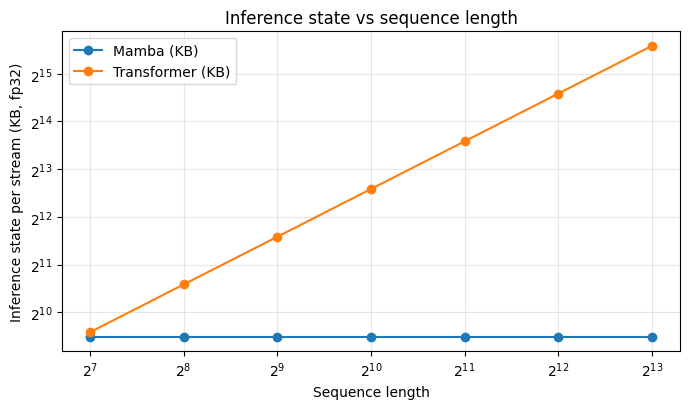

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
for col in ['Mamba (KB)', 'Transformer (KB)']:
    ax.plot(df_state.index, df_state[col], marker='o', label=col)
ax.set_xscale('log', base=2); ax.set_yscale('log', base=2)
ax.set_xlabel('Sequence length'); ax.set_ylabel('Inference state per stream (KB, fp32)')
ax.set_title('Inference state vs sequence length')
ax.grid(True, which='both', alpha=0.3)
ax.legend()
plt.tight_layout(); plt.show()


## Experiment 3 — Loss vs sequence length

Train both models on `seq_len=512` then evaluate at `L ∈ {128, 256, 512, 1024, 2048}`. Mamba should hold up at `L > 512` (its recurrence is content-agnostic). Transformer with positional encoding may degrade out-of-distribution.

We re-pack the test stream at each target `L` so each evaluation is on full-length contexts.


In [15]:
def repack_at_length(stream, L, max_chunks=512):
    chunk_size = L + 1
    n = len(stream) // chunk_size
    n = min(n, max_chunks)
    if n < 1:
        return None
    return torch.tensor(stream[:n * chunk_size], dtype=torch.long).view(n, chunk_size)

len_results = {iface.name: {} for iface in (mamba_iface, xfmr_iface)}
for L in LONG_CONTEXT_LENS:
    data_L = repack_at_length(stream, L, max_chunks=256)
    if data_L is None:
        print(f"L={L}: insufficient data")
        continue
    print(f"\nL={L}  ({data_L.shape[0]} chunks)")
    for iface in (mamba_iface, xfmr_iface):
        bs = max(1, EVAL_BATCH_SIZE // (L // 256 + 1))
        try:
            r = evaluate_test(iface, data_L, batch_size=bs)
            len_results[iface.name][L] = r
            print(f"  {iface.name:12s}  loss={r['loss']:.4f}  ppl={r['perplexity']:.2f}  bpb={r['bpb']:.4f}")
        except Exception as e:
            print(f"  {iface.name:12s}  FAILED: {e!r}")
            len_results[iface.name][L] = None

df_len = pd.DataFrame({
    name: {L: r['bpb'] if r else None for L, r in d.items()}
    for name, d in len_results.items()
})
df_len.index.name = 'seq_len'
df_len



L=128  (256 chunks)


eval Mamba:   0%|          | 0/32 [00:00<?, ?it/s]

  Mamba         loss=2.1962  ppl=8.99  bpb=0.7363


eval Transformer:   0%|          | 0/32 [00:00<?, ?it/s]

  Transformer   loss=2.0828  ppl=8.03  bpb=0.6982

L=256  (256 chunks)


...

eval Mamba:   0%|          | 0/256 [00:00<?, ?it/s]

  Mamba         loss=2.0012  ppl=7.40  bpb=0.6709


eval Transformer:   0%|          | 0/256 [00:00<?, ?it/s]

  Transformer   loss=4.2067  ppl=67.13  bpb=1.4103


,Mamba,Transformer
seq_len,,
128,0.736270,0.698245
256,0.707783,0.665376
512,0.687227,0.641941
1024,0.677903,0.955259
2048,0.670888,1.410270


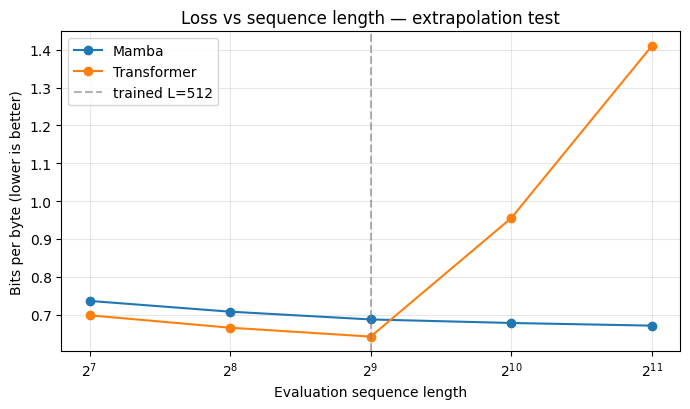

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4.2))
for col in df_len.columns:
    ax.plot(df_len.index, df_len[col], marker='o', label=col)
ax.axvline(SEQ_LEN, color='gray', linestyle='--', alpha=0.6, label=f'trained L={SEQ_LEN}')
ax.set_xscale('log', base=2)
ax.set_xlabel('Evaluation sequence length'); ax.set_ylabel('Bits per byte (lower is better)')
ax.set_title('Loss vs sequence length — extrapolation test')
ax.grid(True, which='both', alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()


## Experiment 4 — Per-position loss

For position `t ∈ [0, seq_len)`, average the loss across all test sequences. A model that uses its context produces a monotonically decreasing curve. A flat curve = the model isn't accumulating context. A U-shape = something pathological.


In [17]:
@torch.no_grad()
def per_position_loss(iface, data, batch_size=8, max_chunks=200):
    n = min(data.shape[0], max_chunks)
    L_minus_1 = data.shape[1] - 1
    accum = torch.zeros(L_minus_1, device=device)
    count = 0
    for i in tqdm(range(0, n, batch_size), desc=f'per-pos {iface.name}'):
        chunk = data[i:i+batch_size].to(device)
        if chunk.size(0) == 0:
            break
        x, y = chunk[:, :-1], chunk[:, 1:]
        logits = iface.forward(x)                            # (B, L, V)
        # Per-position cross-entropy
        log_p = F.log_softmax(logits.float(), dim=-1)
        gather = log_p.gather(-1, y.unsqueeze(-1)).squeeze(-1)   # (B, L)
        nll = -gather                                            # (B, L)
        accum += nll.sum(0)
        count += chunk.size(0)
    return (accum / max(count, 1)).cpu().numpy()

per_pos = {}
for iface in (mamba_iface, xfmr_iface):
    per_pos[iface.name] = per_position_loss(iface, test_data, batch_size=EVAL_BATCH_SIZE)


per-pos Mamba:   0%|          | 0/25 [00:00<?, ?it/s]

per-pos Transformer:   0%|          | 0/25 [00:00<?, ?it/s]

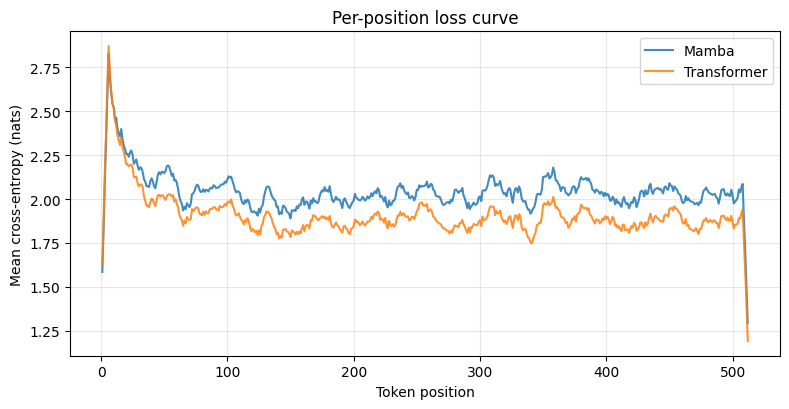

Mamba         pos 0-50 mean = 2.3300   pos last-50 mean = 2.0287   Δ = -0.3013
Transformer   pos 0-50 mean = 2.2659   pos last-50 mean = 1.8758   Δ = -0.3901


In [18]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4.2))
positions = np.arange(1, SEQ_LEN + 1)  # 1-indexed for display
for name, curve in per_pos.items():
    # Smooth slightly with a rolling window
    w = max(1, len(curve) // 50)
    smooth = np.convolve(curve, np.ones(w)/w, mode='same')
    ax.plot(positions, smooth, label=name, alpha=0.85)
ax.set_xlabel('Token position'); ax.set_ylabel('Mean cross-entropy (nats)')
ax.set_title('Per-position loss curve')
ax.grid(True, alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

# Slope of decrease (early vs late)
for name, curve in per_pos.items():
    early = float(curve[:50].mean())
    late  = float(curve[-50:].mean())
    print(f"{name:12s}  pos 0-50 mean = {early:.4f}   pos last-50 mean = {late:.4f}   "
          f"Δ = {late - early:+.4f}")


## Experiment 5 — Selective copying / induction heads

The classic test of in-context retrieval. We construct sequences of the form:

    [A] [B] [filler × n] [A] → score model's P([B] | context)

where `[A]` is a marker token that appears twice and `[B]` is the target the model should "copy" from earlier in the context. We vary the gap `n` to measure recall vs distance.

**Important caveat**: neither model was trained on this synthetic distribution; this tests pure architectural capability for in-context retrieval. Random-baseline performance is `1 / vocab_size`.


In [19]:
import random

V = tokenizer.vocab_size
# Sample fillers from common-ish tokens — avoid weird control IDs.
filler_pool = list(range(10, min(V, 2000)))
marker_pool = list(range(V - 200, V - 100))     # tokens unlikely to appear in fillers
target_pool = list(range(2000, min(V, 3000)))

@torch.no_grad()
def induction_score(iface, n_filler, n_trials=50):
    """Returns (top1_correct_rate, mean_log_p_target, mean_rank_target)"""
    correct, log_ps, ranks = 0, [], []
    rng = random.Random(42 + n_filler)   # deterministic per distance
    for _ in range(n_trials):
        marker = rng.choice(marker_pool)
        target = rng.choice(target_pool)
        fillers = [rng.choice(filler_pool) for _ in range(n_filler)]
        seq = [marker, target] + fillers + [marker]
        ids = torch.tensor([seq], dtype=torch.long, device=device)
        logits = iface.forward(ids)[0, -1]    # logits AFTER last marker
        log_p = F.log_softmax(logits.float(), dim=-1)
        # Score the target token
        log_ps.append(float(log_p[target]))
        # Rank: how many tokens have HIGHER log-prob than target
        rank = int((logits > logits[target]).sum())
        ranks.append(rank)
        if int(logits.argmax()) == target:
            correct += 1
    return {
        'top1':         correct / n_trials,
        'log_p_target': float(np.mean(log_ps)),
        'mean_rank':    float(np.mean(ranks)),
    }

ind_results = {iface.name: {} for iface in (mamba_iface, xfmr_iface)}
for n in INDUCTION_DISTANCES:
    print(f"\nDistance n={n}:")
    for iface in (mamba_iface, xfmr_iface):
        r = induction_score(iface, n_filler=n, n_trials=INDUCTION_TRIALS)
        ind_results[iface.name][n] = r
        print(f"  {iface.name:12s}  top1={r['top1']*100:5.1f}%  log_p={r['log_p_target']:7.3f}  rank={r['mean_rank']:6.0f}")

# Summary frames
df_ind_top1 = pd.DataFrame({
    name: {n: r['top1'] for n, r in d.items()} for name, d in ind_results.items()
})
df_ind_top1.index.name = 'distance'
print('\nTop-1 recall:')
df_ind_top1



Distance n=4:
  Mamba         top1=  0.0%  log_p=-14.553  rank=  1811
  Transformer   top1=  0.0%  log_p=-13.444  rank=  1947

Distance n=8:
  Mamba         top1=  0.0%  log_p=-14.588  rank=  1961
  Transformer   top1=  0.0%  log_p=-13.182  rank=  1986

Distance n=16:
  Mamba         top1=  0.0%  log_p=-13.981  rank=  1896
  Transformer   top1=  0.0%  log_p=-13.153  rank=  2036

Distance n=32:
  Mamba         top1=  0.0%  log_p=-14.490  rank=  1997
  Transformer   top1=  0.0%  log_p=-12.917  rank=  1765

Distance n=64:
  Mamba         top1=  0.0%  log_p=-14.367  rank=  2004
  Transformer   top1=  0.0%  log_p=-13.395  rank=  1874

Distance n=128:
  Mamba         top1=  0.0%  log_p=-14.136  rank=  1830
  Transformer   top1=  0.0%  log_p=-13.460  rank=  1966

Distance n=256:
  Mamba         top1=  0.0%  log_p=-14.020  rank=  2232
  Transformer   top1=  0.0%  log_p=-13.058  rank=  1815

Top-1 recall:


,Mamba,Transformer
distance,,
4,0.0,0.0
8,0.0,0.0
16,0.0,0.0
32,0.0,0.0
64,0.0,0.0
128,0.0,0.0
256,0.0,0.0


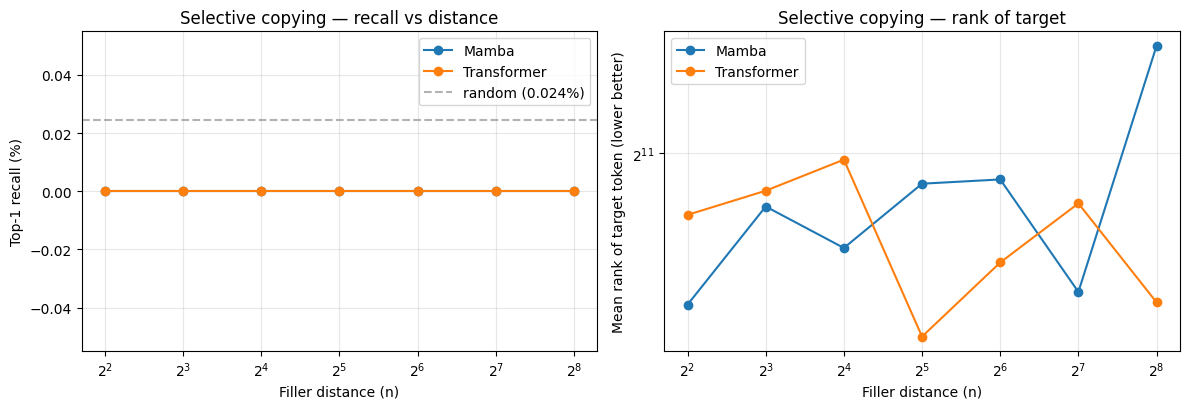

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
random_baseline = 1.0 / tokenizer.vocab_size

# Top-1 recall vs distance
for col in df_ind_top1.columns:
    axes[0].plot(df_ind_top1.index, df_ind_top1[col] * 100, marker='o', label=col)
axes[0].axhline(random_baseline * 100, color='gray', linestyle='--', alpha=0.6,
                label=f'random ({random_baseline*100:.3f}%)')
axes[0].set_xscale('log', base=2)
axes[0].set_xlabel('Filler distance (n)'); axes[0].set_ylabel('Top-1 recall (%)')
axes[0].set_title('Selective copying — recall vs distance')
axes[0].grid(True, which='both', alpha=0.3); axes[0].legend()

# Mean rank of target
df_ind_rank = pd.DataFrame({
    name: {n: r['mean_rank'] for n, r in d.items()} for name, d in ind_results.items()
})
for col in df_ind_rank.columns:
    axes[1].plot(df_ind_rank.index, df_ind_rank[col] + 1, marker='o', label=col)
axes[1].set_xscale('log', base=2); axes[1].set_yscale('log', base=2)
axes[1].set_xlabel('Filler distance (n)'); axes[1].set_ylabel('Mean rank of target token (lower better)')
axes[1].set_title('Selective copying — rank of target')
axes[1].grid(True, which='both', alpha=0.3); axes[1].legend()

plt.tight_layout(); plt.show()


## Experiment 6 — Diversity analysis

Generate `N` completions from each prompt and compute:
* **Self-BLEU** — how similar are the N generations to each other (lower = more diverse)
* **Distinct-1, distinct-2** — fraction of unique unigrams / bigrams (higher = more diverse)
* **Repetition rate** — fraction of bigrams that appear more than once (lower = less degenerate)

A model that always produces the same completion has self-BLEU = 1.0 and very low distinct-n. Detects mode collapse the loss number can't see.


In [21]:
@torch.no_grad()
def generate(iface, prompt_ids, max_new_tokens, temperature=0.8, top_k=40):
    """Gumbel-max sampling — works for any unified interface."""
    cache = iface.allocate_cache(batch_size=1)
    # Prefill: feed prompt tokens one at a time through step()
    for tok in prompt_ids:
        _, cache = iface.step(tok.unsqueeze(0), cache)
    out = []
    next_tok = prompt_ids[-1].unsqueeze(0)
    for _ in range(max_new_tokens):
        logits, cache = iface.step(next_tok, cache)
        logits = logits / max(temperature, 1e-6)
        if top_k:
            v, _ = torch.topk(logits, k=min(top_k, logits.shape[-1]), dim=-1)
            logits = torch.where(logits < v[:, [-1]],
                                 torch.full_like(logits, float('-inf')), logits)
        u = torch.rand_like(logits).clamp(min=1e-9)
        next_tok = torch.argmax(logits + (-torch.log(-torch.log(u))), dim=-1)
        out.append(int(next_tok))
        if int(next_tok) == eos_id:
            break
    return prompt_ids.tolist() + out

print("Generating samples — this can take a few minutes per model...")
generations = {iface.name: {p: [] for p in DIVERSITY_PROMPTS} for iface in (mamba_iface, xfmr_iface)}

for iface in (mamba_iface, xfmr_iface):
    for prompt in DIVERSITY_PROMPTS:
        pids = torch.tensor(tokenizer.encode(prompt, add_special_tokens=False),
                            dtype=torch.long, device=device)
        if pids.numel() == 0:
            pids = torch.tensor([eos_id], dtype=torch.long, device=device)
        for trial in tqdm(range(DIVERSITY_GENS_PER_PROMPT),
                          desc=f'{iface.name}: {prompt!r}'):
            gen_ids = generate(iface, pids, DIVERSITY_MAX_NEW_TOKENS,
                               temperature=DIVERSITY_TEMPERATURE,
                               top_k=DIVERSITY_TOP_K)
            text = tokenizer.decode(gen_ids, skip_special_tokens=True)
            generations[iface.name][prompt].append(text)

# Show one example per prompt per model
for name, by_prompt in generations.items():
    print(f"\n══ {name} sample ══")
    for prompt, texts in list(by_prompt.items())[:2]:
        print(f"  [{prompt!r}] → {texts[0]!r}")


Generating samples — this can take a few minutes per model...


Mamba: 'once upon a time,':   0%|          | 0/20 [00:00<?, ?it/s]

Mamba: 'there was a little girl named':   0%|          | 0/20 [00:00<?, ?it/s]

Mamba: 'the dog ran':   0%|          | 0/20 [00:00<?, ?it/s]

Mamba: 'in a small village,':   0%|          | 0/20 [00:00<?, ?it/s]

Transformer: 'once upon a time,':   0%|          | 0/20 [00:00<?, ?it/s]

Transformer: 'there was a little girl named':   0%|          | 0/20 [00:00<?, ?it/s]

Transformer: 'the dog ran':   0%|          | 0/20 [00:00<?, ?it/s]

Transformer: 'in a small village,':   0%|          | 0/20 [00:00<?, ?it/s]


══ Mamba sample ══
  ['once upon a time,'] → 'once upon a time, a secret club met in a small town. they met under the old tree, sharing tales of treasure and hidden treasures. each friend felt the thrill of adventure, but one day, a traitor caught them. his friends had left, leaving the group to stay in silence. the leader felt betrayed and betrayed. he wanted to share his life with them. one night, the group gathered in a'
  ['there was a little girl named'] → 'there was a little girl named mia. mia loved to play games with her friends. one day, mia found a shiny stone that sparkled like stars. she picked it up and wished to see the world. mia thought, " i want to see the world! " then, a strong wind blew through the garden. mia watched the sun rise, and the leaves danced in the wind. she felt sad because she lost something important.'

══ Transformer sample ══
  ['once upon a time,'] → 'once upon a time, " the ghost said, smiling. kim nodded. " and you can talk to me! " she said. th

In [22]:
def compute_diversity(texts):
    """Returns dict with self-BLEU, distinct-1, distinct-2, repetition_rate."""
    tokenised = [t.split() for t in texts]

    # Self-BLEU: each text scored against the others as references
    smooth = SmoothingFunction().method1
    bleus = []
    for i, hyp in enumerate(tokenised):
        refs = [t for j, t in enumerate(tokenised) if j != i]
        if not refs or not hyp:
            continue
        bleus.append(sentence_bleu(refs, hyp, smoothing_function=smooth))
    self_bleu = float(np.mean(bleus)) if bleus else 0.0

    # Distinct-n
    all_uni = [tok for txt in tokenised for tok in txt]
    all_bi  = [bg for txt in tokenised for bg in zip(txt[:-1], txt[1:])]
    distinct_1 = len(set(all_uni)) / max(len(all_uni), 1)
    distinct_2 = len(set(all_bi))  / max(len(all_bi), 1)

    # Repetition rate: per generation, fraction of bigrams that repeat
    rep = []
    for txt in tokenised:
        if len(txt) < 2: continue
        bgs = list(zip(txt[:-1], txt[1:]))
        c = Counter(bgs)
        rep.append(sum(v for v in c.values() if v > 1) / len(bgs))
    repetition = float(np.mean(rep)) if rep else 0.0

    return {
        'self_bleu':      self_bleu,
        'distinct_1':     distinct_1,
        'distinct_2':     distinct_2,
        'repetition_rate': repetition,
    }

div_results = {}
for name, by_prompt in generations.items():
    per_prompt_metrics = {p: compute_diversity(texts) for p, texts in by_prompt.items()}
    # Average across prompts
    keys = ['self_bleu', 'distinct_1', 'distinct_2', 'repetition_rate']
    div_results[name] = {k: float(np.mean([m[k] for m in per_prompt_metrics.values()]))
                         for k in keys}

df_div = pd.DataFrame(div_results).T
df_div.index.name = 'model'
df_div


,self_bleu,distinct_1,distinct_2,repetition_rate
model,,,,
Mamba,0.195628,0.339358,0.754927,0.058847
Transformer,0.211052,0.340829,0.744952,0.072136


## Summary

Bring the headline numbers into one table. The interpretation:

* `bpb` and `top1/top5` — **lower bpb is better**, **higher top-k is better**. Quality.
* `decode_latency_ms` and `prefill_L*_tps` — **decode is Mamba's selling point**. Lower latency, higher tps = faster serving.
* `state_kb_at_L=512` — **lower is better at fixed L**, but the Mamba advantage compounds at long L (see Experiment 2 plot).
* `induction_top1_at_n=64` — **higher is better**. Tests architectural capability for in-context retrieval.
* `self_bleu` — **lower is more diverse**. `distinct_2` — **higher is more diverse**. `repetition_rate` — **lower is healthier**.


In [23]:
def safe_get(d, *keys, default=float('nan')):
    for k in keys:
        if d is None or k not in d:
            return default
        d = d[k]
    return d

summary = {}
for iface in (mamba_iface, xfmr_iface):
    name = iface.name
    summary[name] = {
        'n_params':                 iface.n_params,
        'test_loss':                results_test[name]['loss'],
        'test_perplexity':          results_test[name]['perplexity'],
        'test_bpb':                 results_test[name]['bpb'],
        'test_top1':                results_test[name]['top1'],
        'test_top5':                results_test[name]['top5'],
        'decode_tps':               results_inf[name]['decode_tps'],
        'decode_latency_ms':        results_inf[name]['decode_latency_ms'],
        f'prefill_L512_tps':        results_inf[name].get('prefill_L512_tps', float('nan')),
        f'state_kb_at_L=512':       iface.state_size_bytes(1, 512) / 1024,
        f'state_kb_at_L=2048':      iface.state_size_bytes(1, 2048) / 1024,
        f'induction_top1_at_n=64':  safe_get(ind_results.get(name, {}).get(64), 'top1'),
        'diversity_self_bleu':      div_results[name]['self_bleu'],
        'diversity_distinct_2':     div_results[name]['distinct_2'],
        'diversity_repetition':     div_results[name]['repetition_rate'],
    }

df_summary = pd.DataFrame(summary).T
df_summary.index.name = 'model'
df_summary


,n_params,test_loss,test_perplexity,test_bpb,test_top1,test_top5,decode_tps,decode_latency_ms,prefill_L512_tps,state_kb_at_L=512,state_kb_at_L=2048,induction_top1_at_n=64,diversity_self_bleu,diversity_distinct_2,diversity_repetition
model,,,,,,,,,,,,,,,
Mamba,5138432.0,2.02643,7.58695,0.679348,0.505973,0.785584,140.192298,7.133060,6354.178694,720.0,720.0,0.0,0.195628,0.754927,0.058847
Transformer,5374208.0,1.89149,6.62924,0.634110,0.528670,0.807565,129.570641,7.717798,56303.810807,3072.0,12288.0,0.0,0.211052,0.744952,0.072136


In [24]:
# Save the consolidated results to JSON for the writeup.
out = {
    'config': {
        'mamba_checkpoint':    MAMBA_CHECKPOINT_PATH,
        'transformer':         HF_TRANSFORMER_MODEL,
        'dataset':             DATASET_NAME,
        'split':               DATASET_SPLIT,
        'lowercase':           LOWERCASE,
        'seq_len':             SEQ_LEN,
        'n_test_stories':      len(ds),
        'bytes_per_token':     bytes_per_token,
    },
    'experiment_1_test':       results_test,
    'experiment_2_inference':  results_inf,
    'experiment_2_state':      df_state.reset_index().to_dict(orient='records'),
    'experiment_3_loss_vs_len': len_results,
    'experiment_4_per_pos':    {k: v.tolist() for k, v in per_pos.items()},
    'experiment_5_induction':  ind_results,
    'experiment_6_diversity':  div_results,
    'summary':                 summary,
}
out_path = 'simplestories_eval_results.json'
with open(out_path, 'w') as f:
    json.dump(out, f, indent=2, default=str)
print(f"Wrote {out_path}")


Wrote simplestories_eval_results.json


---

**Done.** The results are in `simplestories_eval_results.json` plus the dataframes above.

For the writeup, the natural three-act structure is:
1. **Quality**: Experiment 1 (test BPB) and Experiment 6 (diversity) — does Mamba match the transformer at fixed param budget?
2. **Efficiency**: Experiment 2 (decode tps + state size) — does Mamba deliver the predicted serving advantages?
3. **Why**: Experiments 3, 4, 5 — long-context extrapolation, context use, in-context retrieval — explain the architectural differences.
